# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [12]:
#cargamos el archivo

reviews = pd.read_csv("./data/reviews_sentiment.csv", sep = ";")
reviews.head()

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784


In [13]:
#Exploración inicial de los datos
reviews.info()
# tengo 257 filas
# columnas tipo numero:wordcount, Star Rating, sentimentValue 
# hay nulos en columna: titleSentiment 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    object 
 1   Review Text     257 non-null    object 
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    object 
 4   textSentiment   257 non-null    object 
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), object(4)
memory usage: 14.2+ KB


In [14]:
reviews.describe() # me devuelve estadísticos de las columnas numéricas.

# wordcount: tiene una std más alta que mean; esto indica que hay mucha variedad(outliers)
# sentimentValue: también tiene una std muy alta del doble que mea

,wordcount,Star Rating,sentimentValue
count,257.000000,257.000000,257.000000
mean,11.501946,3.420233,0.383849
std,13.159812,1.409531,0.897987
min,1.000000,1.000000,-2.276469
25%,3.000000,3.000000,-0.108144
50%,7.000000,3.000000,0.264091
75%,16.000000,5.000000,0.808384
max,103.000000,5.000000,3.264579


## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

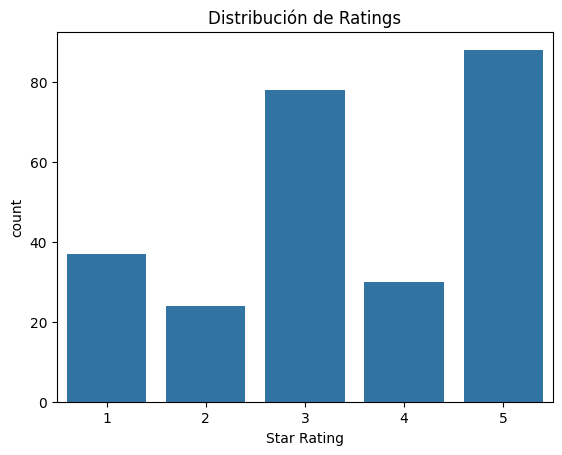

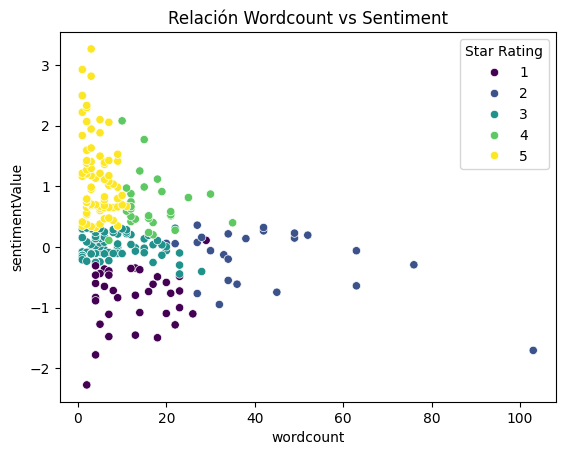

In [15]:
# Distribución de las estrellas
sns.countplot(x='Star Rating', data= reviews)
plt.title('Distribución de Ratings')
plt.show()

# Relación entre palabras y sentimiento coloreado por rating
sns.scatterplot(x='wordcount', y='sentimentValue', hue='Star Rating', data=reviews, palette='viridis')
plt.title('Relación Wordcount vs Sentiment')
plt.show()


In [16]:
# podemos observar que que rating que mas predomina son 3 y 5 estrellas. hay más opiniones positiva, 
# en el scatterplot podemos ver que existe una relación clara entre sentiment value y rating
# los valores mas altos se asocian a un rating de 4,5 estrellas.
# por otro lado, nos eobserva relación clara entre wordcount y rating,por lo que su capacidad predictica será menor.

In [17]:
reviews[['Star Rating', 'wordcount', 'sentimentValue']].corr()
#star rating y sentiment tienen una correlacion postiva muy fuerte.

,Star Rating,wordcount,sentimentValue
Star Rating,1.000000,-0.402059,0.792180
wordcount,-0.402059,1.000000,-0.347232
sentimentValue,0.792180,-0.347232,1.000000


## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [19]:
# Definimos X e y
X = reviews[['wordcount', 'sentimentValue']]
y = reviews['Star Rating']

In [20]:
# Dividimos (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size= 0.20, random_state=42)

# Escalamos al rango [0, 1]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [22]:
# Entreno el modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(y_pred)

[3 5 1 2 1 1 5 1 3 3 3 3 2 5 3 5 3 1 5 5 1 3 5 5 5 1 3 5 5 5 5 4 1 4 3 1 5
 2 3 1 5 2 5 3 3 2 4 4 1 4 5 5]


In [23]:
# revisamos errores
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Accuracy
print("Accuracy train:", accuracy_score(y_train, knn.predict(X_train)))
print("Accuracy test: ", accuracy_score(y_test, y_pred))

Accuracy train: 0.9073170731707317
Accuracy test:  0.8653846153846154


## Evalúa tu modelo

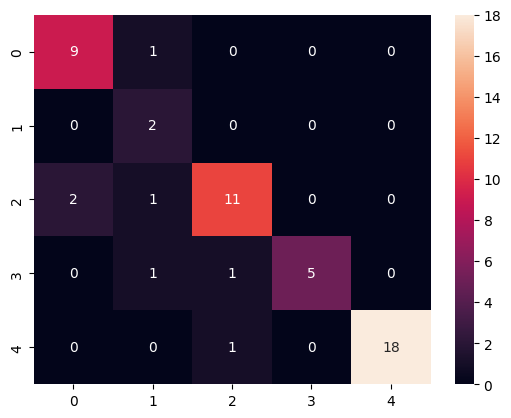

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

# 2. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# no entiendo muy bien esta parte :( 

## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [25]:
accuracy_train = []
accuracy_test = []

for k in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    accuracy_train.append(accuracy_score(y_train, knn.predict(X_train)))
    accuracy_test.append(accuracy_score(y_test, y_pred))

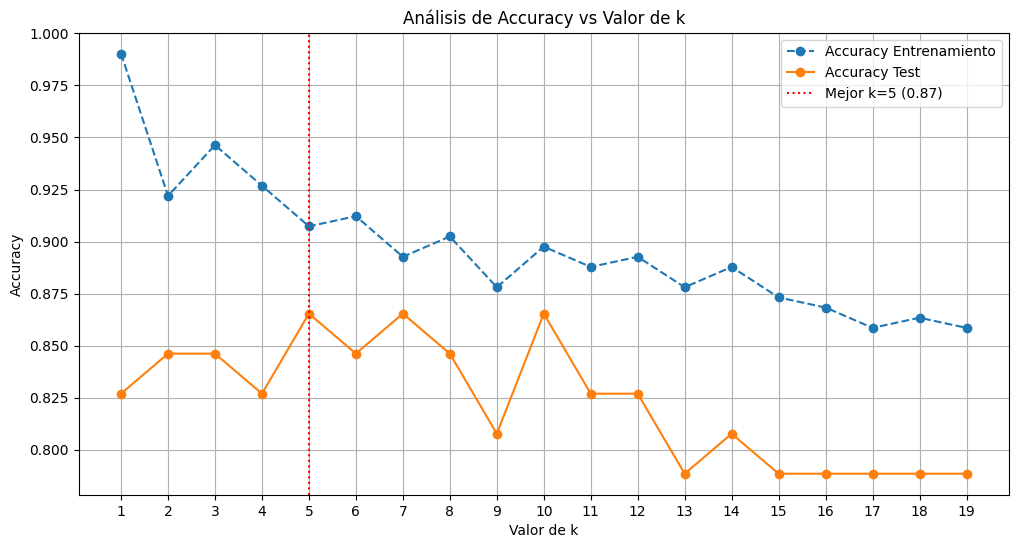

Confirmado: El mejor k es 5


In [26]:
# 1. PRIMERO calculamos cuál es el mejor valor
# Buscamos la posición del valor más alto en la lista de test
mejor_k = accuracy_test.index(max(accuracy_test)) + 1
mejor_acc = max(accuracy_test)

# 2. DESPUÉS dibujamos el gráfico
plt.figure(figsize=(12, 6))
plt.plot(range(1, 20), accuracy_train, label='Accuracy Entrenamiento', marker='o', linestyle='--')
plt.plot(range(1, 20), accuracy_test, label='Accuracy Test', marker='o')

plt.title('Análisis de Accuracy vs Valor de k')
plt.xlabel('Valor de k')
plt.ylabel('Accuracy')
plt.xticks(range(1, 20)) 

# Ahora 'mejor_k' ya existe y no dará error
plt.axvline(x=mejor_k, color='red', linestyle=':', label=f'Mejor k={mejor_k} ({mejor_acc:.2f})')

plt.legend()
plt.grid(True)
plt.show()

print(f"Confirmado: El mejor k es {mejor_k}")

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [29]:
nuevos_datos = [[5, 1]]

# 1. Lo escalamos exactamente igual que hicimos con el train
review_nueva_scal = scaler.transform(nuevos_datos)


#2. Predicciones
# Usamos el mejor_k que sacamos en el ejercicio anterior( en la gráfica)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(review_nueva_scal)
print(y_pred)


[5]


c:\Users\tifaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
